# Imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
import utils
import ray
ray.init(num_cpus=4)


from utils import run_comparable_sims

from utils import make_mal_and_benign_driver_lists,run_ring_sim_variable_cfm

Libraries loaded.


# Load detection model:

In [3]:
from detector_dev.Process_RingRoad_Simulation.attack_param_sweep_single_lane import run_sim_with_attack

from detector_dev.Process_RingRoad_Simulation.get_rec_errors_normalized_single_lane import \
    get_trajectory_timeseries,filter_timeseries_dict_for_length

from detector_dev.Process_RingRoad_Simulation.get_rec_errors_normalized_single_lane import get_rec_errors_normalized as get_RE_normal

from utils import get_rec_errors





import torch
from Detectors.Deep_Learning.AutoEncoders.utils import *

from sklearn import metrics

from sklearn.metrics import f1_score




def get_rec_errors_absolute(sim_file_path,
    model,
    warmup_period=100):
    
    return get_rec_errors(sim_file_path,model,warmup_period)


def get_rec_errors_normalized(sim_file_path,
    model,
    warmup_period=100,
    normalizing_factors=[13.91463681, 10.29542389, 47.98582978,  7.21631525]):
    
    timeseries_dict = get_trajectory_timeseries(csv_path=sim_file_path,warmup_period=warmup_period)

    timeseries_dict = filter_timeseries_dict_for_length(timeseries_dict,seq_len=100)

    rec_errors_normalized = get_RE_normal(timeseries_dict,
        model,
        normalizing_factors=normalizing_factors,
        warmup_period=warmup_period)
    
    return rec_errors_normalized





model_normalized = get_cnn_lstm_ae_model(n_features=4)
model_normalized_path = 'models/cnn_lstm_ae_normalized_ring_detector.pt'
model_normalized.load_state_dict(torch.load(model_normalized_path))

model_abs = get_cnn_lstm_ae_model(n_features=4)
MODEL_PATH = '/Users/vanderbilt/Desktop/General_research_tools/Anti-Flow/detector_dev/models/cnn_lstm_ae_ringlength600_1lane__1.0percentGPS.pt'
model_abs.load_state_dict(torch.load(MODEL_PATH,map_location=torch.device('cpu')))


print('Detection models loaded.')

Detection models loaded.


# Baseline:

In [4]:
driver_controller_list_with_attack,driver_controller_list_without_attack = make_mal_and_benign_driver_lists(0.0,0.0)

In [52]:
run_ring_sim_variable_cfm(ring_length=600,
    driver_controller_list=driver_controller_list_without_attack,
    num_lanes=1,
    sim_time=500,
    want_render=True,
    emission_path='data')

print('Finished with sim.')

Number of classes of driver: 40
Running ring simulation, ring length: 600


/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Round 0, Return: 3019.7468997180144
data/ring_variable_cfm_20240724-1523071721852587.8410041-0_emission.csv data
Average, std velocities: 6.596720817449438, 0.0
Average, std outflows: 0.0, 0.0
Average, std avg_trip_energy: nan, nan
Average, std avg_trip_time: nan, nan
Average, std total_completed_trips: 0.0, 0.0
Average, std returns: 3019.7468997180144, 0.0
Total time: 87.64614605903625
steps/second: 76.82636232668253
Finished with sim.


In [53]:
benign_sim_file_path = 'data/ring_variable_cfm_20240724-1523071721852587.8410041-0_emission.csv'

In [64]:
reload(utils)
from utils import get_rec_errors

In [65]:
rec_errors_abs_benign = get_rec_errors_absolute(sim_file_path=benign_sim_file_path,
                                                model=model_abs,
                                                warmup_period=100)
print('Found absolute rec errors')

Data loaded, total time: 1.5992100238800049
Vehicles processed: 40

Found absolute rec errors


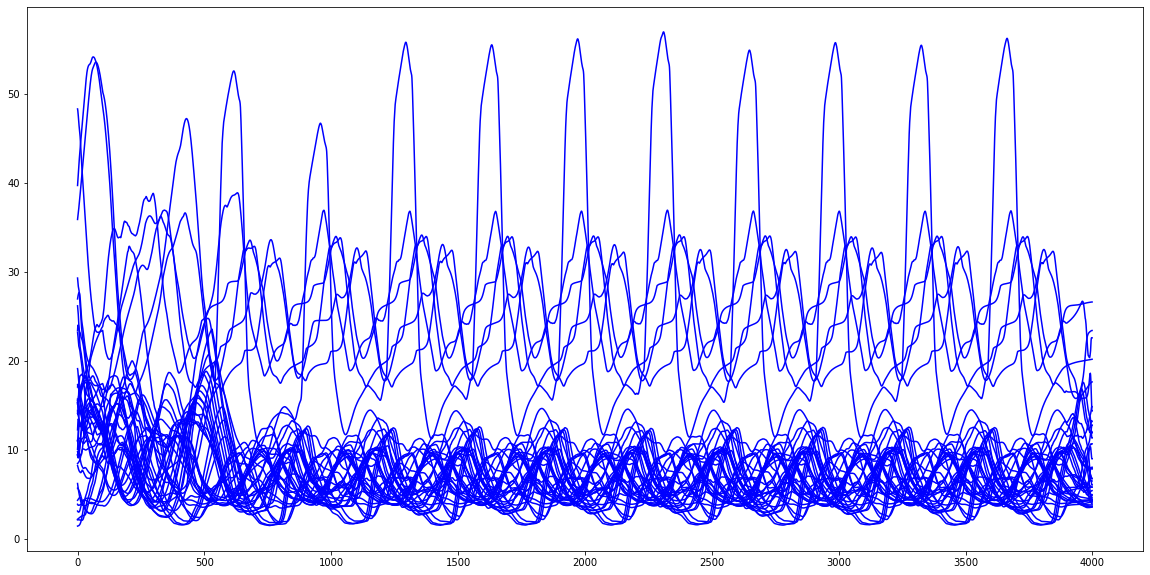

In [68]:
plt.figure(figsize=[20,10])
for veh_id in rec_errors_abs_benign:
    e = rec_errors_abs_benign[veh_id]
    plt.plot(e,'b')

In [74]:
rec_errors_normalized_benign = get_rec_errors_normalized(sim_file_path=benign_sim_file_path,
                                                model=model_normalized)
print('Found normalized rec errors')

Data loaded, total time: 1.9365911483764648
Vehicles processed: 40/40, total compute time: 171.76505684852622

Total time to calculate loses: 172.40017795562744
Found normalized rec errors


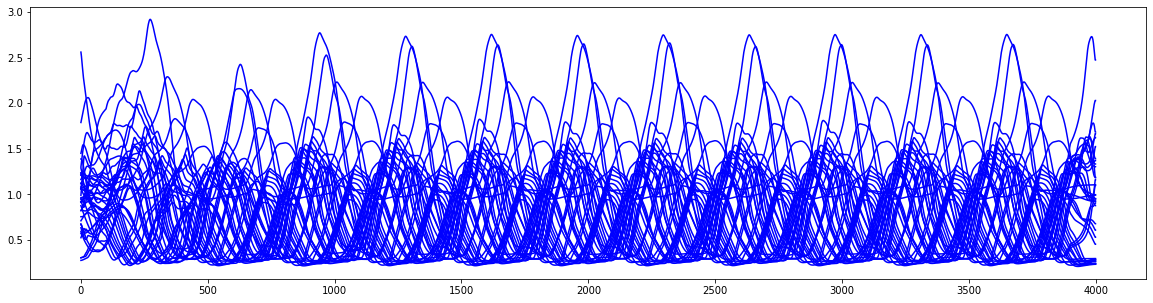

In [92]:
plt.figure(figsize=[20,5])
for veh_id in rec_errors_normalized_benign :
    e = rec_errors_normalized_benign [veh_id][1]
    plt.plot(e,'b')

# Max speed based compromise:

In [4]:
from Adversaries_testing.adversarial_controllers import *

In [21]:
import Adversaries_testing.adversarial_controllers
from importlib import reload
reload(Adversaries_testing.adversarial_controllers)
from Adversaries_testing.adversarial_controllers import *
from copy import deepcopy

In [28]:
max_speed_compromised = 3.0

driver_controller_list_with_attack = deepcopy(driver_controller_list_without_attack)

driver_controller_list_with_attack[-1][1][1]['V_m'] = max_speed_compromised
driver_controller_list_with_attack[-1][0] = 'ACC_adv_max_speed_1'


driver_controller_list_with_attack[-2][1][1]['V_m'] = max_speed_compromised
driver_controller_list_with_attack[-2][0] = 'ACC_adv_max_speed_2'

print('Defined adversaries')

Defined adversaries


In [29]:
print(driver_controller_list_with_attack[-3])

['ACC_k_11.54_k_20.03_h1.89_V_m15.48d_m10.0', (<class 'Adversaries.controllers.car_following_adversarial.ACC_Benign'>, {'k_1': 1.5371541331938539, 'k_2': 0.0303756902285498, 'h': 1.8929884017919094, 'V_m': 15.483050570982611, 'd_min': 10.0}), 1]


In [85]:
run_ring_sim_variable_cfm(ring_length=600,
    driver_controller_list=driver_controller_list_with_attack,
    num_lanes=1,
    sim_time=500,
    want_render=True,
    emission_path='data')

print('Finished with sim.')

Number of classes of driver: 40
Running ring simulation, ring length: 600


/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Round 0, Return: 1524.4079089225122
data/ring_variable_cfm_20240724-1655451721858145.093421-0_emission.csv data
Average, std velocities: 3.0731745781047555, 0.0
Average, std outflows: 0.0, 0.0
Average, std avg_trip_energy: nan, nan
Average, std avg_trip_time: nan, nan
Average, std total_completed_trips: 0.0, 0.0
Average, std returns: 1524.4079089225122, 0.0
Total time: 107.08162784576416
steps/second: 73.0786594739315
Finished with sim.


In [88]:
max_speed_comp_sim_file_path = 'data/ring_variable_cfm_20240724-1655451721858145.093421-0_emission.csv'

In [89]:
rec_errors_max_speed_comp_abs = get_rec_errors_absolute(sim_file_path=max_speed_comp_sim_file_path,
                                                model=model_abs,
                                                warmup_period=100)
print('Found absolute rec errors')

Data loaded, total time: 1.6326699256896973
Vehicles processed: 40

Found absolute rec errors


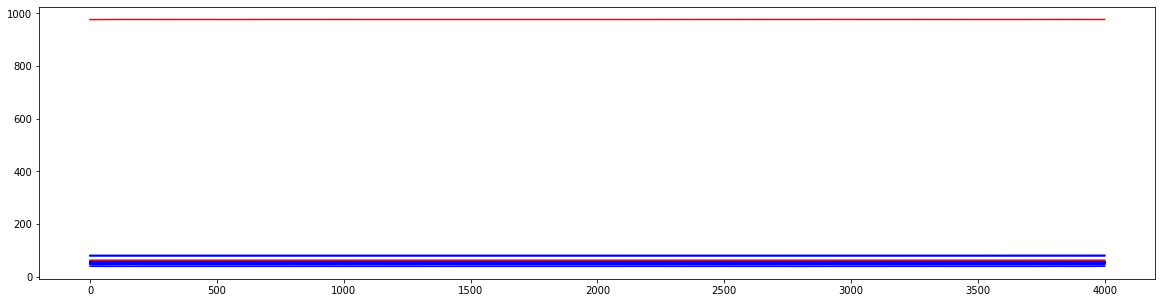

In [93]:
plt.figure(figsize=[20,5])
for veh_id in rec_errors_max_speed_comp_abs:
    e = rec_errors_max_speed_comp_abs[veh_id]
    if('adv' not in veh_id):
        plt.plot(e,'b')
    else:
        plt.plot(e,'r')

In [33]:
rec_errors_max_speed_normalized = get_rec_errors(max_speed_comp_sim_file_path,model)

Data loaded, total time: 1.6730461120605469
Vehicles processed: 40/40, total compute time: 170.06887197494507

Total time to calculate loses: 170.67743015289307


Text(0.5, 0, 'Time [s]')

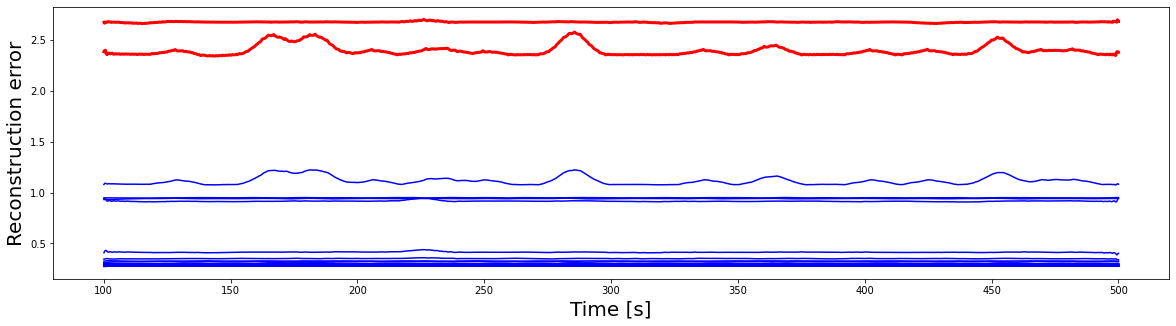

In [42]:
plt.figure(figsize=[20,5])

non_adv_rec_errors = []
times = []

for veh_id in rec_errors:
    if('adv' not in veh_id):
        t = rec_errors_max_speed_normalized[veh_id][0]
        e = rec_errors_max_speed_normalized[veh_id][1]
        plt.plot(t,e,'b')
        
t = rec_errors_max_speed_normalized['ACC_adv_max_speed_1_0'][0]
e = rec_errors_max_speed_normalized['ACC_adv_max_speed_1_0'][1]
plt.plot(t,e,'r',linewidth = 3.0)

t = rec_errors_max_speed_normalized['ACC_adv_max_speed_2_0'][0]
e = rec_errors_max_speed_normalized['ACC_adv_max_speed_2_0'][1]
plt.plot(t,e,'r',linewidth = 3.0,label='Adversarial')

# plt.legend(fontsize=20)

plt.ylabel('Reconstruction error (normalized)',fontsize=20)
plt.xlabel('Time [s]',fontsize=20)

# Radar warping attack:

In [5]:
import Adversaries_testing.adversarial_controllers
import imp
imp.reload(Adversaries_testing.adversarial_controllers)
# import Adversaries_testing.adversarial_controllers
from Adversaries_testing.adversarial_controllers import *

In [6]:
driver_controller_list_with_attack = deepcopy(driver_controller_list_without_attack)

In [7]:
radar_warp_slope = -0.3


g = radar_warp_slope
Total_Attack_Duration = 10.0
display_attack_info = True
warmup_steps = 500

# first ACC compromised:
label = 'ACC_comp_radar_warp_1'
driver_controller_list_with_attack[-1][0] = label

comp_controller_instance = deepcopy(driver_controller_list_with_attack[-1][1][1])

comp_controller_instance['g'] =  g
comp_controller_instance['Total_Attack_Duration'] =  Total_Attack_Duration
comp_controller_instance['display_attack_info'] =  display_attack_info
comp_controller_instance['warmup_steps'] =  warmup_steps

driver_controller_list_with_attack[-1][1] = (ACC_comp_inject_radar,comp_controller_instance)


# Second ACC compromised:
label = 'ACC_comp_radar_warp_2'
driver_controller_list_with_attack[-2][0] = label

comp_controller_instance = deepcopy(driver_controller_list_with_attack[-2][1][1])

comp_controller_instance['g'] =  g
comp_controller_instance['Total_Attack_Duration'] =  Total_Attack_Duration
comp_controller_instance['display_attack_info'] =  display_attack_info
comp_controller_instance['warmup_steps'] =  warmup_steps

driver_controller_list_with_attack[-2][1] = (ACC_comp_inject_radar,comp_controller_instance)


print('Defined radar warp adversaries.')

Defined radar warp adversaries.


In [8]:
run_ring_sim_variable_cfm(ring_length=600,
    driver_controller_list=driver_controller_list_with_attack,
    num_lanes=1,
    sim_time=500,
    want_render=True,
    emission_path='data')

print('Finished with sim.')

Number of classes of driver: 40
Running ring simulation, ring length: 600
Spawning radar inject compromised ACC, attack frequency: 78.97125773537778
Will engage in multiple attacks.
Spawning radar inject compromised ACC, attack frequency: 92.62569130663121
Will engage in multiple attacks.
Beginning radar warp attack: ACC_comp_radar_warp_1_0 Time: 79.0
Radar warp attack finished. veh_id: ACC_comp_radar_warp_1_0, slope: -0.3, duration: 10.0, time: 89.10000000000001
Beginning radar warp attack: ACC_comp_radar_warp_2_0 Time: 92.7
Radar warp attack finished. veh_id: ACC_comp_radar_warp_2_0, slope: -0.3, duration: 10.0, time: 102.80000000000001
Beginning radar warp attack: ACC_comp_radar_warp_1_0 Time: 168.10000000000002
Radar warp attack finished. veh_id: ACC_comp_radar_warp_1_0, slope: -0.3, duration: 10.0, time: 178.20000000000002
Beginning radar warp attack: ACC_comp_radar_warp_2_0 Time: 195.5
Radar warp attack finished. veh_id: ACC_comp_radar_warp_2_0, slope: -0.3, duration: 10.0, time:

/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Round 0, Return: 2190.222159383616
data/ring_variable_cfm_20240725-1143471721925827.023585-0_emission.csv data
Average, std velocities: 5.242855862465685, 0.0
Average, std outflows: 0.0, 0.0
Average, std avg_trip_energy: nan, nan
Average, std avg_trip_time: nan, nan
Average, std total_completed_trips: 0.0, 0.0
Average, std returns: 2190.222159383616, 0.0
Total time: 178.2231569290161
steps/second: 43.85554571068973
Finished with sim.


In [9]:
sim_radar_warp_file_path = 'data/ring_variable_cfm_20240725-1143471721925827.023585-0_emission.csv'

In [10]:
rec_errors_radar_warp_comp_abs = get_rec_errors_absolute(sim_file_path=sim_radar_warp_file_path,
                                                model=model_abs,
                                                warmup_period=100)
print('Found absolute rec errors')

Data loaded, total time: 3.0608839988708496
Vehicles processed: 40

Found absolute rec errors


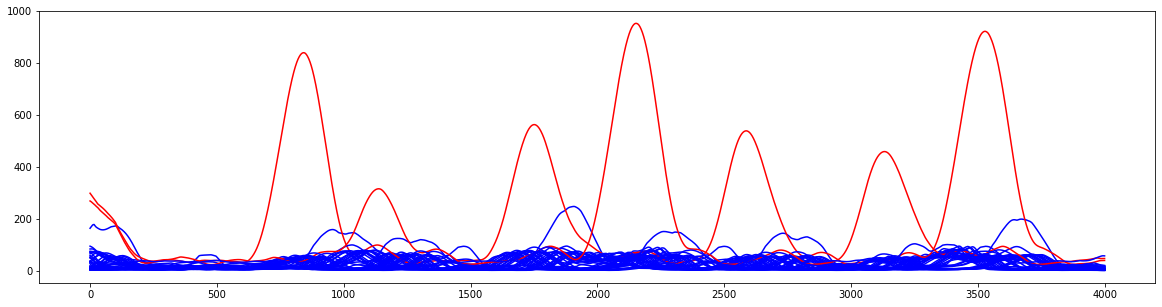

In [11]:
plt.figure(figsize=[20,5])
for veh_id in rec_errors_radar_warp_comp_abs:
    e = rec_errors_radar_warp_comp_abs[veh_id]
    if('comp' not in veh_id):
        plt.plot(e,'b')
    else:
        plt.plot(e,'r')

In [13]:
# CHANGE SLOPE OF ATTACK:
driver_controller_list_with_attack = deepcopy(driver_controller_list_without_attack)
radar_warp_slope = 2.0


g = radar_warp_slope
Total_Attack_Duration = 10.0
display_attack_info = True
warmup_steps = 500

# first ACC compromised:
label = 'ACC_comp_radar_warp_1'
driver_controller_list_with_attack[-1][0] = label

comp_controller_instance = deepcopy(driver_controller_list_with_attack[-1][1][1])

comp_controller_instance['g'] =  g
comp_controller_instance['Total_Attack_Duration'] =  Total_Attack_Duration
comp_controller_instance['display_attack_info'] =  display_attack_info
comp_controller_instance['warmup_steps'] =  warmup_steps

driver_controller_list_with_attack[-1][1] = (ACC_comp_inject_radar,comp_controller_instance)


# Second ACC compromised:
label = 'ACC_comp_radar_warp_2'
driver_controller_list_with_attack[-2][0] = label

comp_controller_instance = deepcopy(driver_controller_list_with_attack[-2][1][1])

comp_controller_instance['g'] =  g
comp_controller_instance['Total_Attack_Duration'] =  Total_Attack_Duration
comp_controller_instance['display_attack_info'] =  display_attack_info
comp_controller_instance['warmup_steps'] =  warmup_steps

driver_controller_list_with_attack[-2][1] = (ACC_comp_inject_radar,comp_controller_instance)


print('Defined radar warp adversaries.')

Defined radar warp adversaries.


In [14]:
run_ring_sim_variable_cfm(ring_length=600,
    driver_controller_list=driver_controller_list_with_attack,
    num_lanes=1,
    sim_time=500,
    want_render=True,
    emission_path='data')

print('Finished with sim.')

Number of classes of driver: 40
Running ring simulation, ring length: 600
Spawning radar inject compromised ACC, attack frequency: 60.09634489306737
Will engage in multiple attacks.
Spawning radar inject compromised ACC, attack frequency: 66.65760388117961
Will engage in multiple attacks.
Beginning radar warp attack: ACC_comp_radar_warp_1_0 Time: 60.1
Beginning radar warp attack: ACC_comp_radar_warp_2_0 Time: 66.8
Radar warp attack finished. veh_id: ACC_comp_radar_warp_1_0, slope: 2.0, duration: 10.0, time: 70.2
Radar warp attack finished. veh_id: ACC_comp_radar_warp_2_0, slope: 2.0, duration: 10.0, time: 76.9
Beginning radar warp attack: ACC_comp_radar_warp_1_0 Time: 130.4
Radar warp attack finished. veh_id: ACC_comp_radar_warp_1_0, slope: 2.0, duration: 10.0, time: 140.5
Beginning radar warp attack: ACC_comp_radar_warp_2_0 Time: 143.6
Radar warp attack finished. veh_id: ACC_comp_radar_warp_2_0, slope: 2.0, duration: 10.0, time: 153.70000000000002
Beginning radar warp attack: ACC_comp

/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Round 0, Return: 2753.606191275206
data/ring_variable_cfm_20240725-1201211721926881.5231638-0_emission.csv data
Average, std velocities: 6.193153202261156, 0.0
Average, std outflows: 0.0, 0.0
Average, std avg_trip_energy: nan, nan
Average, std avg_trip_time: nan, nan
Average, std total_completed_trips: 0.0, 0.0
Average, std returns: 2753.606191275206, 0.0
Total time: 99.74465584754944
steps/second: 74.72310552432455
Finished with sim.


In [15]:
sim_radar_warp_file_path = 'data/ring_variable_cfm_20240725-1201211721926881.5231638-0_emission.csv'

rec_errors_radar_warp_comp_abs = get_rec_errors_absolute(sim_file_path=sim_radar_warp_file_path,
                                                model=model_abs,
                                                warmup_period=100)
print('Found absolute rec errors')

Data loaded, total time: 1.6998987197875977
Vehicles processed: 40

Found absolute rec errors


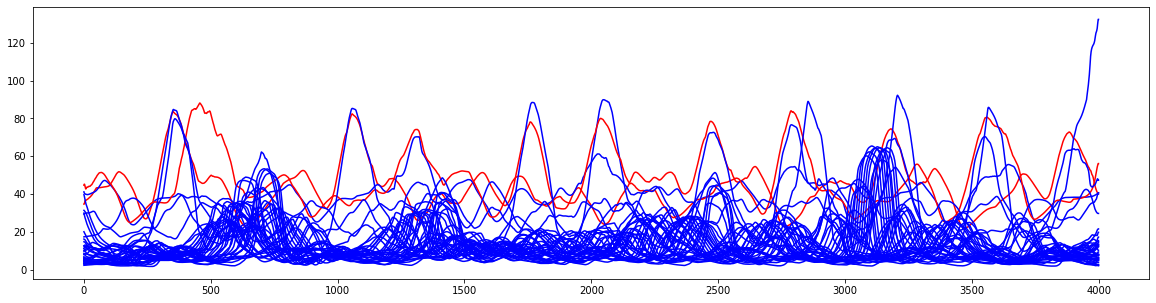

In [16]:
plt.figure(figsize=[20,5])
for veh_id in rec_errors_radar_warp_comp_abs:
    e = rec_errors_radar_warp_comp_abs[veh_id]
    if('comp' not in veh_id):
        plt.plot(e,'b')
    else:
        plt.plot(e,'r')

In [17]:
# CHANGE SLOPE OF ATTACK:
driver_controller_list_with_attack = deepcopy(driver_controller_list_without_attack)
radar_warp_slope = 0.5


g = radar_warp_slope
Total_Attack_Duration = 10.0
display_attack_info = True
warmup_steps = 500

# first ACC compromised:
label = 'ACC_comp_radar_warp_1'
driver_controller_list_with_attack[-1][0] = label

comp_controller_instance = deepcopy(driver_controller_list_with_attack[-1][1][1])

comp_controller_instance['g'] =  g
comp_controller_instance['Total_Attack_Duration'] =  Total_Attack_Duration
comp_controller_instance['display_attack_info'] =  display_attack_info
comp_controller_instance['warmup_steps'] =  warmup_steps

driver_controller_list_with_attack[-1][1] = (ACC_comp_inject_radar,comp_controller_instance)


# Second ACC compromised:
label = 'ACC_comp_radar_warp_2'
driver_controller_list_with_attack[-2][0] = label

comp_controller_instance = deepcopy(driver_controller_list_with_attack[-2][1][1])

comp_controller_instance['g'] =  g
comp_controller_instance['Total_Attack_Duration'] =  Total_Attack_Duration
comp_controller_instance['display_attack_info'] =  display_attack_info
comp_controller_instance['warmup_steps'] =  warmup_steps

driver_controller_list_with_attack[-2][1] = (ACC_comp_inject_radar,comp_controller_instance)


print('Defined radar warp adversaries.')

run_ring_sim_variable_cfm(ring_length=600,
    driver_controller_list=driver_controller_list_with_attack,
    num_lanes=1,
    sim_time=500,
    want_render=True,
    emission_path='data')

print('Finished with sim.')

Defined radar warp adversaries.
Number of classes of driver: 40
Running ring simulation, ring length: 600
Spawning radar inject compromised ACC, attack frequency: 85.07180050850465
Will engage in multiple attacks.
Spawning radar inject compromised ACC, attack frequency: 79.90097040201552
Will engage in multiple attacks.
Beginning radar warp attack: ACC_comp_radar_warp_2_0 Time: 80.10000000000001
Beginning radar warp attack: ACC_comp_radar_warp_1_0 Time: 85.10000000000001
Radar warp attack finished. veh_id: ACC_comp_radar_warp_2_0, slope: 0.5, duration: 10.0, time: 90.2
Radar warp attack finished. veh_id: ACC_comp_radar_warp_1_0, slope: 0.5, duration: 10.0, time: 95.2
Beginning radar warp attack: ACC_comp_radar_warp_2_0 Time: 170.20000000000002
Beginning radar warp attack: ACC_comp_radar_warp_1_0 Time: 180.3
Radar warp attack finished. veh_id: ACC_comp_radar_warp_2_0, slope: 0.5, duration: 10.0, time: 180.3
Radar warp attack finished. veh_id: ACC_comp_radar_warp_1_0, slope: 0.5, duratio

/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Round 0, Return: 2653.2028865361212
data/ring_variable_cfm_20240725-1716441721945804.822475-0_emission.csv data
Average, std velocities: 5.994289790966375, 0.0
Average, std outflows: 0.0, 0.0
Average, std avg_trip_energy: nan, nan
Average, std avg_trip_time: nan, nan
Average, std total_completed_trips: 0.0, 0.0
Average, std returns: 2653.2028865361212, 0.0
Total time: 102.62613224983215
steps/second: 73.1653083852314
Finished with sim.


Data loaded, total time: 2.7613279819488525
Vehicles processed: 40

Found absolute rec errors


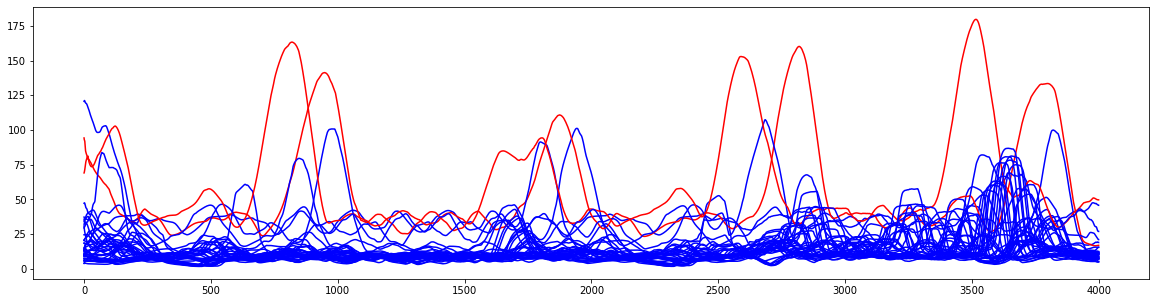

In [18]:
sim_radar_warp_file_path = 'data/ring_variable_cfm_20240725-1716441721945804.822475-0_emission.csv'

rec_errors_radar_warp_comp_abs = get_rec_errors_absolute(sim_file_path=sim_radar_warp_file_path,
                                                model=model_abs,
                                                warmup_period=100)
print('Found absolute rec errors')

plt.figure(figsize=[20,5])
for veh_id in rec_errors_radar_warp_comp_abs:
    e = rec_errors_radar_warp_comp_abs[veh_id]
    if('comp' not in veh_id):
        plt.plot(e,'b')
    else:
        plt.plot(e,'r')

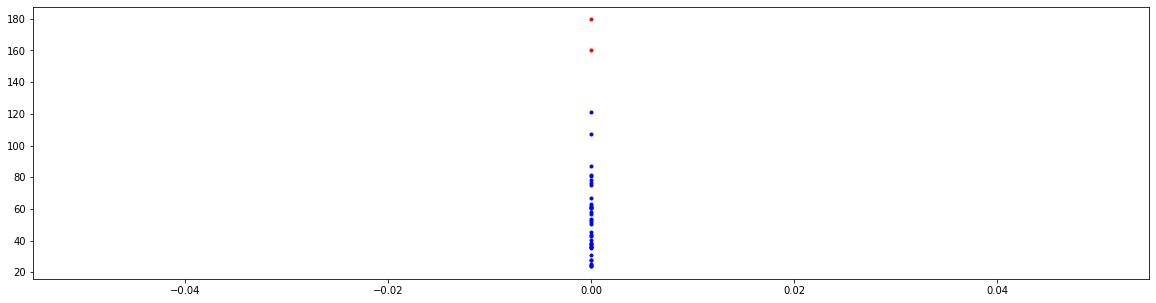

In [19]:
plt.figure(figsize=[20,5])
for veh_id in rec_errors_radar_warp_comp_abs:
    e = rec_errors_radar_warp_comp_abs[veh_id]
    if('comp' not in veh_id):
        plt.plot(np.max(e),'b.')
    else:
        plt.plot(np.max(e),'r.')

In [20]:
for veh_id in rec_errors_radar_warp_comp_abs:
    e = rec_errors_radar_warp_comp_abs[veh_id]
    if('comp' not in veh_id):
        if(np.max(e) > 60.0):
            print('False positive: '+str(veh_id))

False positive: bando_ftl_ovm_a0.59_b21.26_s01.99_s12.69_Vm7.57_0
False positive: bando_ftl_ovm_a0.63_b21.19_s02.16_s12.83_Vm8.5_0
False positive: bando_ftl_ovm_a0.56_b21.5_s02.28_s12.65_Vm8.94_0
False positive: bando_ftl_ovm_a0.53_b22.99_s02.35_s12.76_Vm9.11_0
False positive: bando_ftl_ovm_a0.75_b20.97_s02.39_s13.1_Vm8.95_0
False positive: bando_ftl_ovm_a0.54_b22.48_s02.44_s12.79_Vm8.61_0
False positive: bando_ftl_ovm_a0.66_b21.66_s02.21_s12.49_Vm9.11_0
False positive: bando_ftl_ovm_a0.54_b21.04_s02.32_s12.92_Vm8.82_0
False positive: bando_ftl_ovm_a0.67_b21.75_s02.4_s12.57_Vm9.86_0
False positive: bando_ftl_ovm_a0.8_b21.16_s02.36_s13.24_Vm9.58_0
False positive: bando_ftl_ovm_a0.45_b21.14_s02.27_s13.19_Vm8.77_0
False positive: bando_ftl_ovm_a0.67_b22.19_s02.2_s12.95_Vm8.99_0
False positive: bando_ftl_ovm_a0.62_b22.17_s02.39_s12.7_Vm8.43_0
False positive: bando_ftl_ovm_a0.68_b20.88_s02.26_s12.61_Vm8.46_0
